# Distribution Fitting

## Objective

Compare Normal, Exponential, Gamma, Lognormal, and Uniform distributions for `age`, `absences`, `G1`, `G2`, and `G3` using fitted parameters and the Kolmogorov-Smirnov statistic.

## Hypotheses and assumptions

For each candidate, $H_0$ states that the observed values follow the fitted distribution; $H_1$ states that they do not. Observations are treated as independent and the candidate distributions are continuous. Because age, absences, and grades are discrete, the continuous-fit p-values are approximate. Fitting parameters on the same data also makes the ordinary KS p-values exploratory rather than exact.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_processed_data
from src.statistics import StatisticalAnalyzer

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_processed_data()
analyzer = StatisticalAnalyzer(df)

print("Dataset loaded successfully")
print("Numeric columns:", list(analyzer.numeric_cols))

Dataset loaded successfully
Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


## Fit candidate distributions

The largest p-value is reported as the *best tested* fit. A candidate is labeled a good fit only when $p>0.05$.

In [2]:
distribution_columns = [
    "age",
    "absences",
    "G1",
    "G2",
    "G3"
]

all_distribution_results = {}
distribution_summary_rows = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for column in distribution_columns:
        result = analyzer.fit_distribution(column)
        all_distribution_results[column] = result

        distribution_summary_rows.append({
            "column": column,
            "best_fit": result["best_fit"],
            "p_value": result["best_p_value"],
            "good_fit": result["good_fit"]
        })

distribution_summary = pd.DataFrame(
    distribution_summary_rows
)

print(distribution_summary)

     column   best_fit       p_value  good_fit
0       age     Normal  8.029233e-18     False
1  absences     Normal  8.175943e-27     False
2        G1  Lognormal  4.932368e-04     False
3        G2      Gamma  3.801585e-04     False
4        G3     Normal  4.564115e-09     False


## Results and conclusion

Normal was the best tested fit for age, absences, and G3; Lognormal for G1; and Gamma for G2. Every p-value was below 0.05, so none was a statistically good fit. This agrees with Week 1 evidence that the grade variables are non-normal. “Best fit” is relative only and must not be described as a good model.

In [3]:
distribution_output_file = (
    REPORTS_DIR
    / "distribution_fitting_summary.csv"
)

distribution_summary.to_csv(
    distribution_output_file,
    index=False
)

print("Saved to:", distribution_output_file)

Saved to: /Users/hsumonsan/Statistics-superstars/reports/distribution_fitting_summary.csv


## Visual assessment

Each histogram is overlaid with its best tested density. The plots support the statistical conclusion by showing discreteness, skew, or shape differences that the continuous curves do not fully capture.

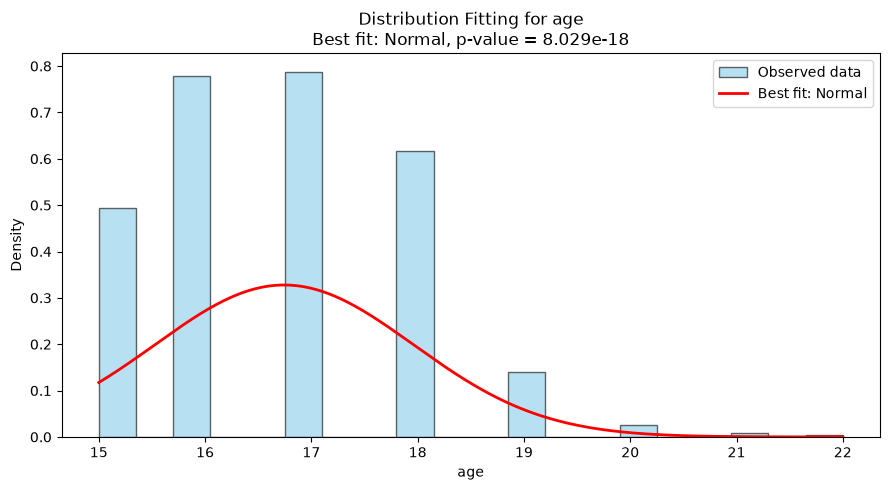

Saved: /Users/hsumonsan/Statistics-superstars/reports/figures/distribution_fit_age.png


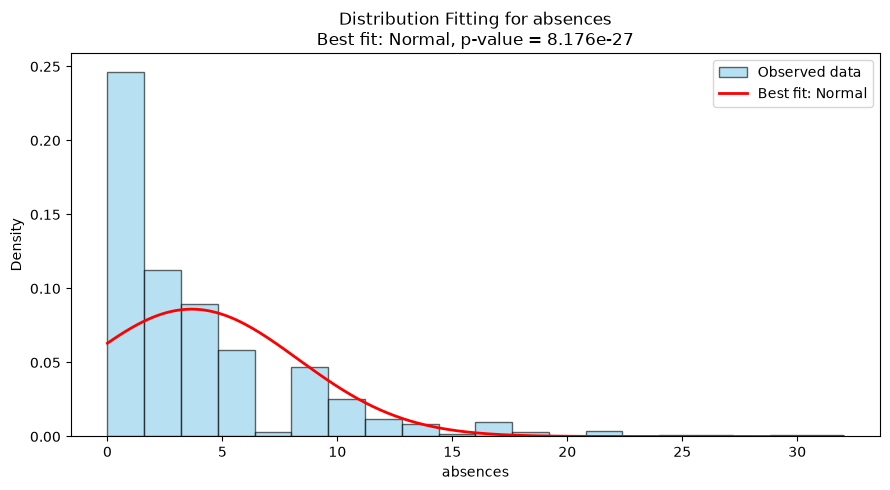

Saved: /Users/hsumonsan/Statistics-superstars/reports/figures/distribution_fit_absences.png


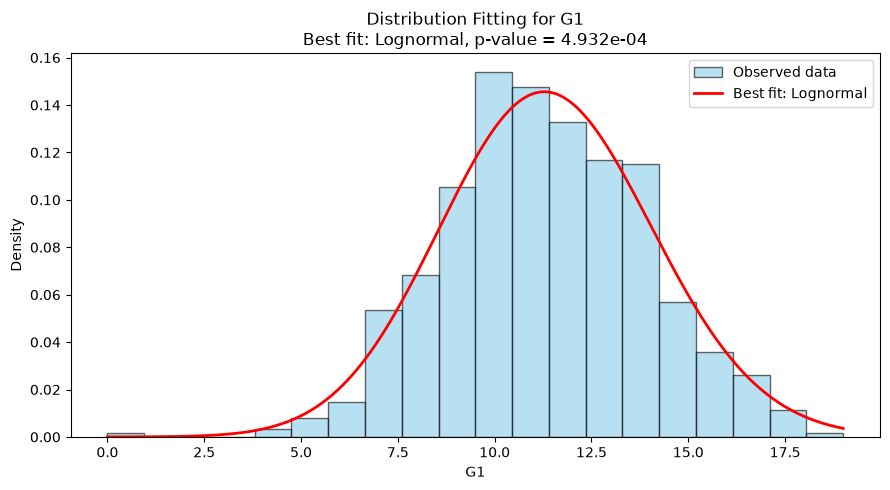

Saved: /Users/hsumonsan/Statistics-superstars/reports/figures/distribution_fit_G1.png


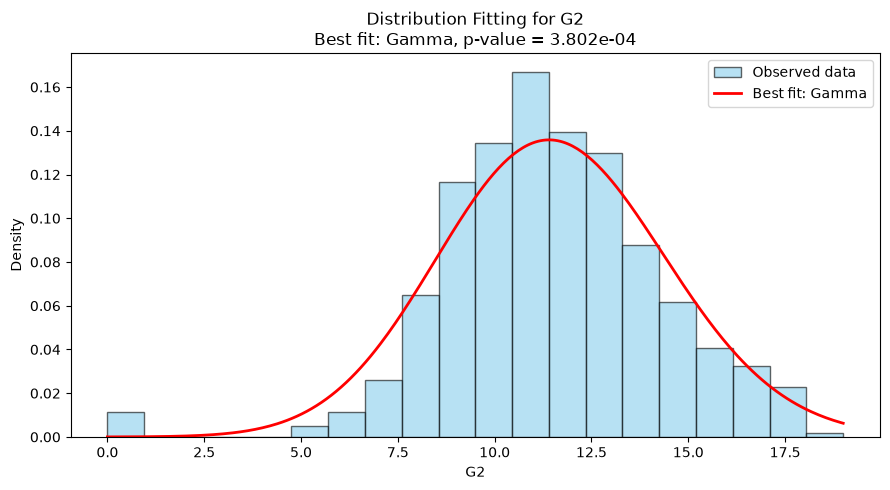

Saved: /Users/hsumonsan/Statistics-superstars/reports/figures/distribution_fit_G2.png


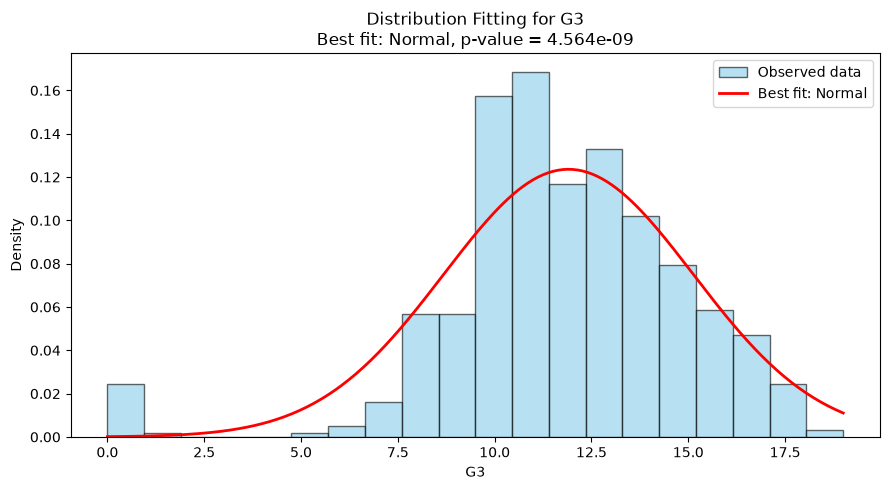

Saved: /Users/hsumonsan/Statistics-superstars/reports/figures/distribution_fit_G3.png


In [4]:
distribution_objects = {
    "Normal": stats.norm,
    "Exponential": stats.expon,
    "Gamma": stats.gamma,
    "Lognormal": stats.lognorm,
    "Uniform": stats.uniform
}

for column in distribution_columns:
    data = df[column].dropna()

    result = all_distribution_results[column]
    best_name = result["best_fit"]
    best_p_value = result["best_p_value"]

    fitted_result = result["results"][best_name]
    parameters = fitted_result["parameters"]
    distribution = distribution_objects[best_name]

    x_values = np.linspace(
        data.min(),
        data.max(),
        300
    )

    y_values = distribution.pdf(
        x_values,
        *parameters
    )

    plt.figure(figsize=(9, 5))

    plt.hist(
        data,
        bins=20,
        density=True,
        alpha=0.6,
        color="skyblue",
        edgecolor="black",
        label="Observed data"
    )

    plt.plot(
        x_values,
        y_values,
        color="red",
        linewidth=2,
        label=f"Best fit: {best_name}"
    )

    plt.title(
        f"Distribution Fitting for {column}\n"
        f"Best fit: {best_name}, p-value = {best_p_value:.3e}"
    )

    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()

    figure_file = (
        FIGURES_DIR
        / f"distribution_fit_{column}.png"
    )

    plt.savefig(
        figure_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", figure_file)

## Final conclusion

No tested continuous distribution adequately represents the selected variables. Week 3 visualizations should display the observed distributions directly and avoid assuming normality without a clear justification.